# Day 1 — M5 Data Exploration

**Goal:** Load the three M5 CSV files and understand what's inside each one.

**What you'll learn:**
- How to load CSV files into pandas
- The structure of the M5 dataset
- Why the data is in 'wide' format and what 'long' format means
- How calendar and price data link to sales

Run each cell by clicking it and pressing **Shift + Enter**.

## Step 1 — Import libraries

Like `require()` in PHP or `import` in JavaScript — we're loading the tools we need.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make pandas show more columns when we print DataFrames
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Step 2 — Load the calendar file (the easiest one to start with)

This is the smallest file and the easiest to understand. It maps the M5's strange `d_1, d_2, d_3...` day labels back to real dates, and flags events like Christmas, Easter, and SNAP benefit payment days.

In [12]:
calendar = pd.read_csv('../data/raw/calendar.csv')

print(f'Calendar shape: {calendar.shape[0]} rows × {calendar.shape[1]} columns')
print(f'Date range: {calendar["date"].min()} to {calendar["date"].max()}')
calendar.head(10)

Calendar shape: 1969 rows × 14 columns
Date range: 2011-01-29 to 2016-06-19


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


**What you're seeing:**
- `date` — the real calendar date
- `wm_yr_wk` — the M5's internal week number (used to join price data)
- `weekday`, `wday`, `month`, `year` — date breakdowns
- `d` — the day label (`d_1` = first day of data, `d_2` = second, etc.)
- `event_name_1`, `event_type_1` — first event on this date (Christmas, Easter, etc.)
- `event_name_2`, `event_type_2` — second event (rarely populated)
- `snap_CA`, `snap_TX`, `snap_WI` — SNAP benefit payment days for California/Texas/Wisconsin (1 = payment day)

**Think of this as a lookup table** — every other piece of data uses the `d` column to refer to a specific day.

In [13]:
# Check what types of events exist
print('Event types in the dataset:')
print(calendar['event_type_1'].value_counts())
print('\nExample event names:')
print(calendar[calendar['event_name_1'].notna()][['date', 'event_name_1', 'event_type_1']].head(15))

Event types in the dataset:
event_type_1
Religious    55
National     52
Cultural     37
Sporting     18
Name: count, dtype: int64

Example event names:
           date    event_name_1 event_type_1
8    2011-02-06       SuperBowl     Sporting
16   2011-02-14   ValentinesDay     Cultural
23   2011-02-21   PresidentsDay     National
39   2011-03-09       LentStart    Religious
46   2011-03-16       LentWeek2    Religious
47   2011-03-17   StPatricksDay     Cultural
50   2011-03-20       Purim End    Religious
85   2011-04-24  OrthodoxEaster    Religious
87   2011-04-26      Pesach End    Religious
96   2011-05-05   Cinco De Mayo     Cultural
99   2011-05-08    Mother's day     Cultural
121  2011-05-30     MemorialDay     National
122  2011-05-31  NBAFinalsStart     Sporting
134  2011-06-12    NBAFinalsEnd     Sporting
141  2011-06-19    Father's day     Cultural


## Step 3 — Load the sales data

This is the **big** file (~125 MB). It contains daily unit sales for 30,490 items across 10 stores over 1,941 days. It's in **wide format** — each day is a separate column. This is unusual and we'll need to reshape it later.

Loading takes ~30 seconds. Be patient.

In [14]:
sales = pd.read_csv('../data/raw/sales_train_evaluation.csv')

print(f'Sales shape: {sales.shape[0]:,} rows × {sales.shape[1]:,} columns')
print(f'Memory used: {sales.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# Look at just the first few rows and first few columns
sales.iloc[:5, :10]

Sales shape: 30,490 rows × 1,947 columns
Memory used: 463.3 MB


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0


**What you're seeing:**
- Each **row** = one specific product in one specific store (called a 'series')
- `id` — unique identifier for the series (e.g., `HOBBIES_1_001_CA_1_evaluation`)
- `item_id` — the product code (e.g., `HOBBIES_1_001`)
- `dept_id` — the department (`FOODS_1`, `FOODS_2`, `FOODS_3`, `HOBBIES_1`, `HOBBIES_2`, `HOUSEHOLD_1`, `HOUSEHOLD_2`)
- `cat_id` — the broad category (`FOODS`, `HOBBIES`, `HOUSEHOLD`)
- `store_id` — which store (`CA_1`, `CA_2`, `TX_1`, etc.)
- `state_id` — the state (`CA`, `TX`, `WI`)
- `d_1`, `d_2`, `d_3`, ... `d_1941` — daily sales for each of the 1,941 days

**This is what 'wide format' means** — instead of one row per day, we have one row per series and the days are columns.

In [15]:
# What stores and categories are in the data?
print('Stores:', sales['store_id'].unique())
print('Categories:', sales['cat_id'].unique())
print('Departments:', sales['dept_id'].unique())
print(f'\nTotal unique items: {sales["item_id"].nunique():,}')
print(f'Total series (item × store): {len(sales):,}')

Stores: ['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']
Categories: ['HOBBIES' 'HOUSEHOLD' 'FOODS']
Departments: ['HOBBIES_1' 'HOBBIES_2' 'HOUSEHOLD_1' 'HOUSEHOLD_2' 'FOODS_1' 'FOODS_2'
 'FOODS_3']

Total unique items: 3,049
Total series (item × store): 30,490


## Step 4 — Filter to our scope: FOODS department, 3 stores

We don't need all 30,490 series. Our report says we focus on the **FOODS department** in **stores CA_1, TX_1, WI_1**. Let's filter.

In [16]:
# Filter
scope = sales[
    (sales['cat_id'] == 'FOODS') &
    (sales['store_id'].isin(['CA_1', 'TX_1', 'WI_1']))
].copy()

print(f'Series in our scope: {len(scope):,}')
print(f'By store:')
print(scope.groupby('store_id').size())
print(f'\nBy subcategory:')
print(scope.groupby('dept_id').size())

Series in our scope: 4,311
By store:
store_id
CA_1    1437
TX_1    1437
WI_1    1437
dtype: int64

By subcategory:
dept_id
FOODS_1     648
FOODS_2    1194
FOODS_3    2469
dtype: int64


## Step 5 — Quick look at one product's sales over time

Let's pick one product in one store and plot its daily sales. This is how you'll spot patterns — seasonality, promotions, stockouts.

In [17]:
# Pick the first series in our scope
one_series = scope.iloc[0]
print(f'Looking at: {one_series["id"]}')
print(f'Product: {one_series["item_id"]} in store {one_series["store_id"]}')

# Extract just the daily sales (the d_1, d_2, ... columns)
day_cols = [c for c in scope.columns if c.startswith('d_')]
daily_sales = one_series[day_cols].values.astype(int)

print(f'\nTotal days: {len(daily_sales)}')
print(f'Total units sold: {daily_sales.sum():,}')
print(f'Average daily sales: {daily_sales.mean():.2f}')
print(f'Days with zero sales: {(daily_sales == 0).sum()}')

Looking at: FOODS_1_001_CA_1_evaluation
Product: FOODS_1_001 in store CA_1

Total days: 1941
Total units sold: 1,526
Average daily sales: 0.79
Days with zero sales: 1095


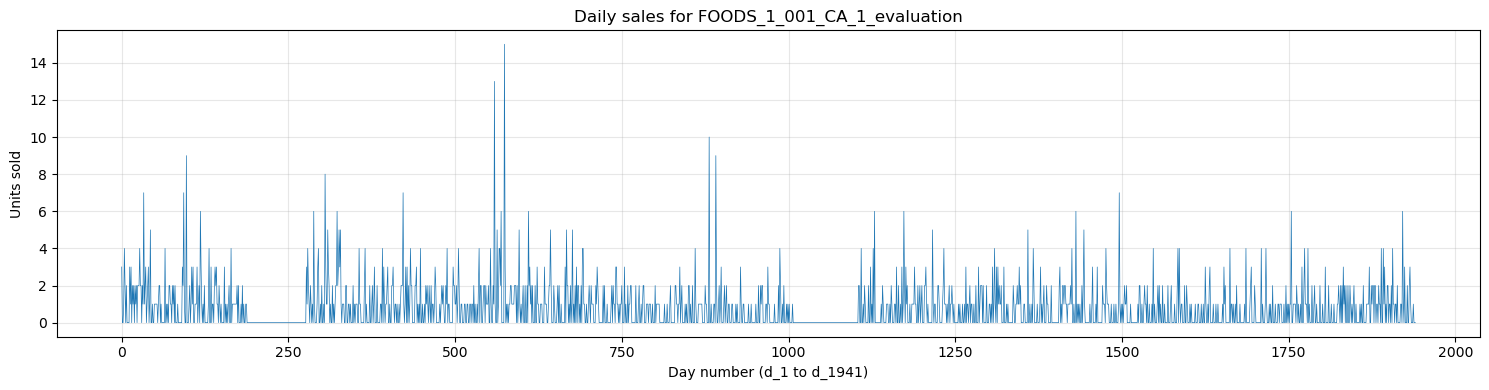

In [18]:
# Plot the daily sales
plt.figure(figsize=(15, 4))
plt.plot(daily_sales, linewidth=0.5)
plt.title(f'Daily sales for {one_series["id"]}')
plt.xlabel('Day number (d_1 to d_1941)')
plt.ylabel('Units sold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Load the prices file

Same idea, smaller file. Prices change weekly, not daily.

In [19]:
prices = pd.read_csv('../data/raw/sell_prices.csv')

print(f'Prices shape: {prices.shape[0]:,} rows × {prices.shape[1]} columns')
prices.head(10)

Prices shape: 6,841,121 rows × 4 columns


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
5,CA_1,HOBBIES_1_001,11330,8.26
6,CA_1,HOBBIES_1_001,11331,8.26
7,CA_1,HOBBIES_1_001,11332,8.26
8,CA_1,HOBBIES_1_001,11333,8.26
9,CA_1,HOBBIES_1_001,11334,8.26


**What you're seeing:**
- `store_id` — which store
- `item_id` — which product
- `wm_yr_wk` — week number (same as in `calendar.csv` — this is how they link)
- `sell_price` — the price that week

Each item × store × week combination has one row.

## Step 7 — How the three files connect

```
      calendar.csv
      ┌──────────────┐
      │ d_1 → date_1 │
      │ d_2 → date_2 │
      │ d_3 → date_3 │
      │ ...          │
      │ wm_yr_wk     │ ────────┐
      └──────────────┘         │
             │                 │
             │ (we'll join     │ (joined to)
             │  on d_*)        │
             ▼                 ▼
      sales_train         sell_prices.csv
      _evaluation.csv     ┌──────────────────────┐
      ┌──────────────┐    │ store + item + week  │
      │ id, item,    │    │     → price          │
      │ store, etc.  │    └──────────────────────┘
      │ d_1...d_1941 │
      └──────────────┘
```

**Tomorrow (Day 2)** we'll do these joins to create one big table where each row is one day of sales for one item in one store, with the date, event flags, and price all attached.

For today, just make sure all three files loaded successfully.

## Step 8 — Sanity check (must all return ✅)

In [20]:
checks = {
    'calendar has ~1969 rows':     len(calendar) > 1900,
    'calendar has date column':    'date' in calendar.columns,
    'sales has 30490 rows':        len(sales) == 30490,
    'sales has FOODS category':    'FOODS' in sales['cat_id'].unique(),
    'scope has ~3 stores worth':   100 < len(scope) < 20000,
    'prices loaded':               len(prices) > 1000000,
    'one_series total > 0':        daily_sales.sum() > 0,
}

for name, passed in checks.items():
    icon = '✅' if passed else '❌'
    print(f'{icon} {name}')

if all(checks.values()):
    print('\n🎉 Day 1 complete! All checks passed. Ready for Day 2.')
else:
    print('\n⚠️ Some checks failed. Review the cells above before moving on.')

✅ calendar has ~1969 rows
✅ calendar has date column
✅ sales has 30490 rows
✅ sales has FOODS category
✅ scope has ~3 stores worth
✅ prices loaded
✅ one_series total > 0

🎉 Day 1 complete! All checks passed. Ready for Day 2.


## What to take away from Day 1

By end of today you should be able to answer:

1. **What's in each of the 3 CSV files?**
   - `calendar.csv` = date lookup + events + SNAP flags
   - `sales_train_evaluation.csv` = daily unit sales (wide format)
   - `sell_prices.csv` = weekly prices per item per store

2. **What does 'wide vs long' mean?**
   - Wide = one column per day (current sales format — hard to work with)
   - Long = one row per day (what we want)

3. **How do the files link together?**
   - sales `d_*` columns link to calendar via the `d` column
   - sales + prices link via `store_id` + `item_id` + `wm_yr_wk`

4. **What is our scope?**
   - FOODS department only
   - 3 stores: CA_1, TX_1, WI_1
   - Roughly 4,500-5,000 series total

If you can answer these — you're ready for Day 2.

## When ready, tell me "Day 1 complete" and I'll generate Day 2.